In [1]:
!pip install -qr requirements.txt

DEPRECATION: Loading egg at /opt/homebrew/Cellar/tbb/2021.12.0/lib/python3.12/site-packages/TBB-0.2-py3.12-macosx-13.0-arm64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.1.1 -> 24.2
[notice] To update, run: /opt/homebrew/opt/python@3.12/bin/python3.12 -m pip install --upgrade pip


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from scipy.io import mmread
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# node2vec
from node2vec import Node2Vec

# deep stuff
import torch
from torch_geometric.utils import from_networkx

/opt/homebrew/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from src.community_results import community_metrics, plot_communities, community_size_hist
from src.clustering import label_propagation, louvain, leiden, kmeans, optics
from src.DGIModel import DGIModel
from src.GAT import  GAT, contrastive_loss
from src.tune import tune, tune_variance_contrastive

In [5]:
data_path = './data'

enron_path = f'{data_path}/email_enron_only.mtx'
univ_path = f'{data_path}/email_univ.edges'

In [6]:
# assume undirected graph
def read_adj_file(file, skip_rows: int = 0):
    lines = []
    with open(file, 'r') as f:
        lines = f.readlines()

    E = np.asarray([l.split() for l in lines[skip_rows:]]).astype(int)
    # index from 0
    E = E - E.min()

    adj = np.zeros((E.max() + 1, E.max() + 1))

    for (u, v) in E:
        adj[u, v] = 1
        adj[v, u] = 1

    return adj

# Load datasets

In [7]:
graphs = dict()

In [8]:
# not in standard mtx format
graphs['univ'] = nx.Graph(read_adj_file(univ_path))
graphs['univ'].number_of_nodes(), graphs['univ'].number_of_edges(), graphs['univ'].is_directed()

(1133, 5451, False)

In [9]:
graphs['enron'] = nx.Graph(mmread(enron_path).toarray())
graphs['enron'].number_of_nodes(), graphs['enron'].number_of_edges(), graphs['enron'].is_directed()

(143, 623, False)

In [10]:
graphs['karate'] = nx.karate_club_graph()
graphs['karate'].number_of_nodes(), graphs['karate'] .number_of_edges(), graphs['karate'].is_directed()

(34, 78, False)

# Select Dataset

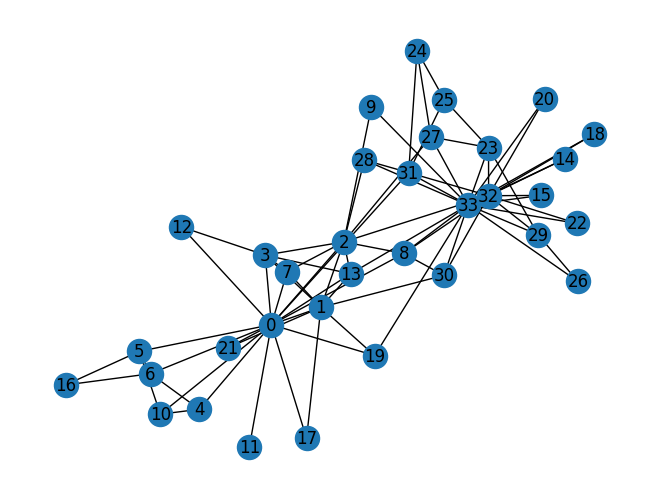

In [11]:
sel_graph = 'karate'
g = graphs[sel_graph]
nx.draw(g, with_labels=True)

# Apply graph based clustering

## Label Propagation

### Hyperparameter selection

2 approaches will be considered for label propagation:
1. Single run label propagation.
2. Label propagation with aggregation on multiple runs.

Single run experiment:

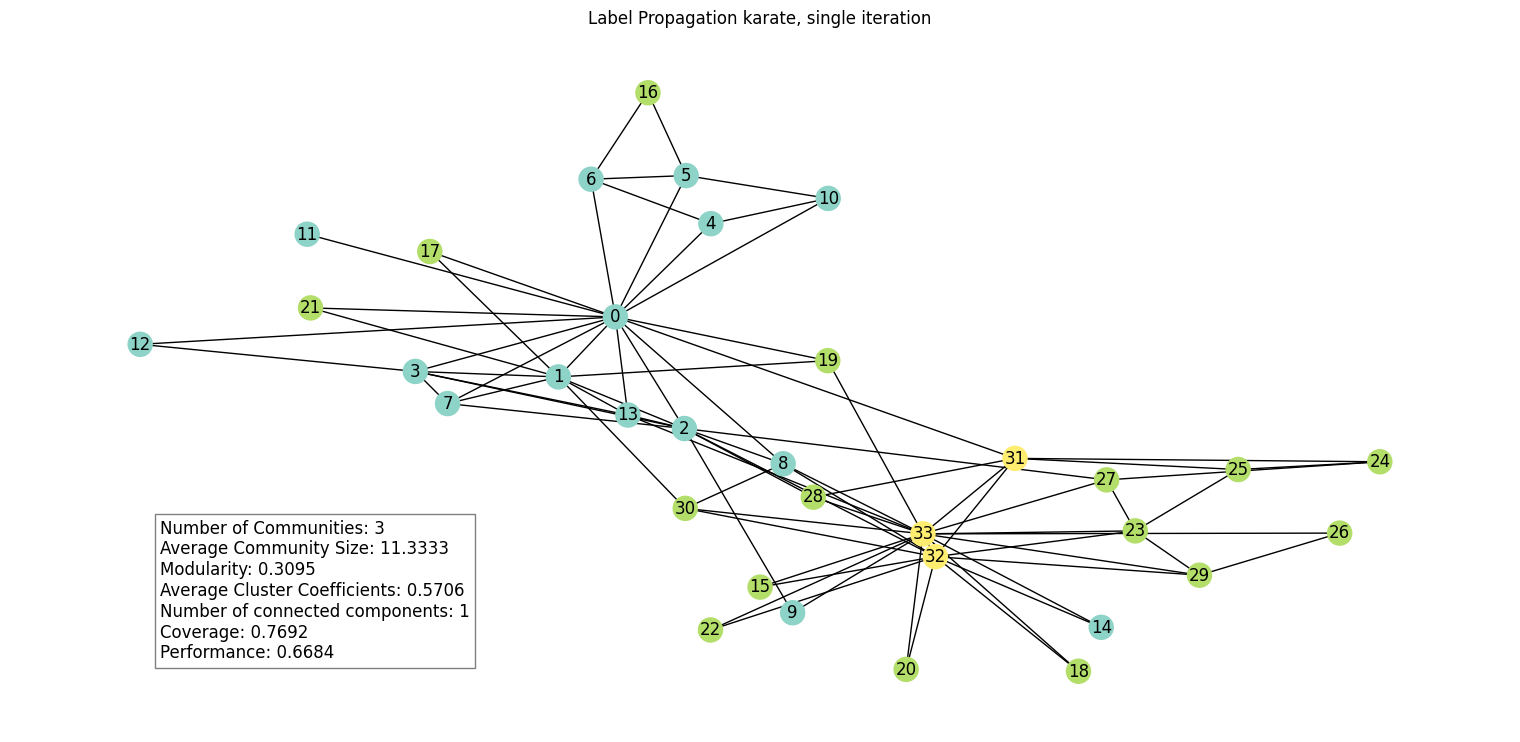

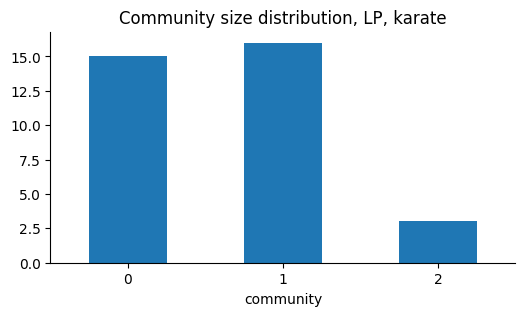

In [12]:
# single run
lp_labels = label_propagation(g)

# Calculate metrics for LP
lp_metrics = community_metrics(g, lp_labels)
plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}, single iteration", metrics=lp_metrics)
community_size_hist(lp_labels, title=f"Community size distribution, LP, {sel_graph}")

In [13]:
best_lp_modularity = lp_metrics["Modularity"]
best_i = 1

Experiments with 5 and 15 iterations:

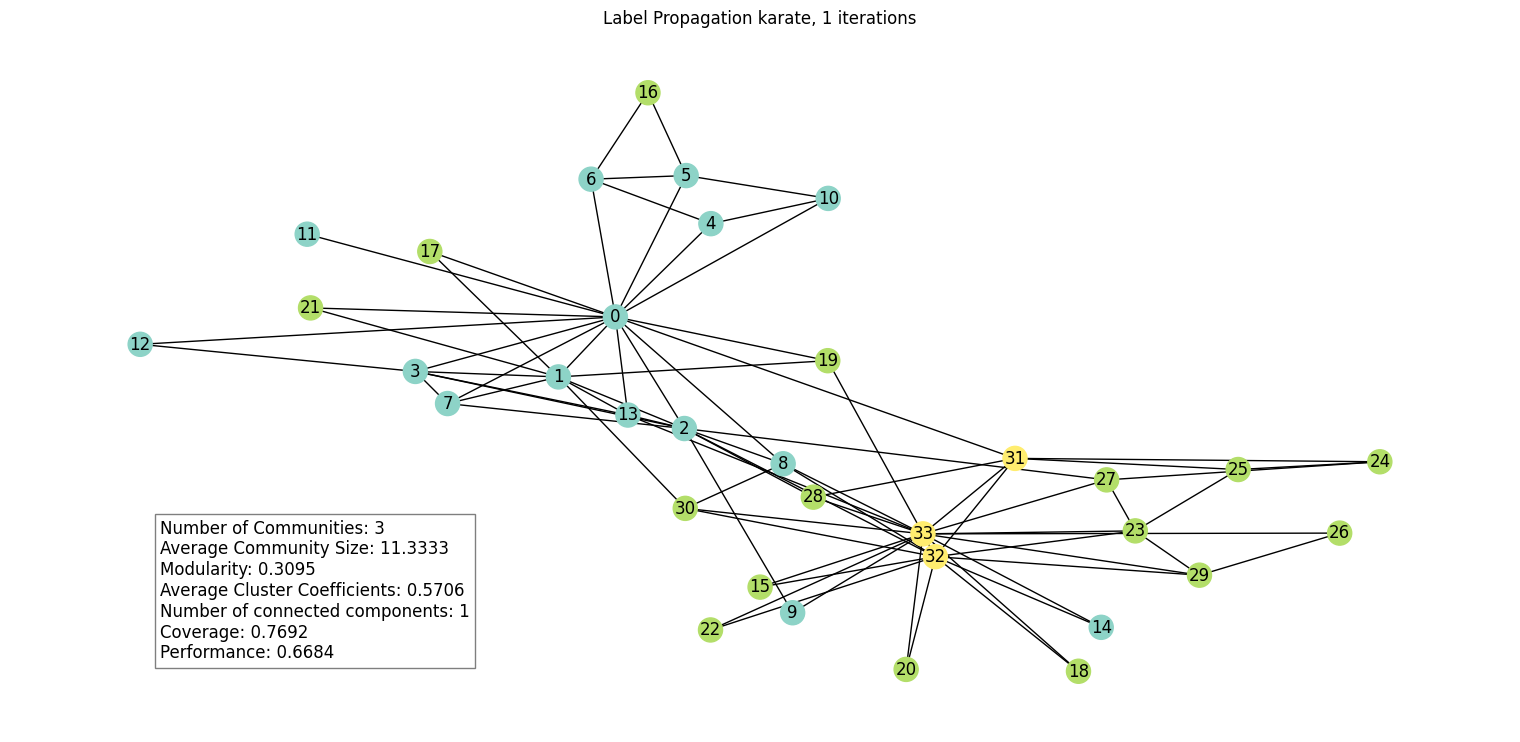

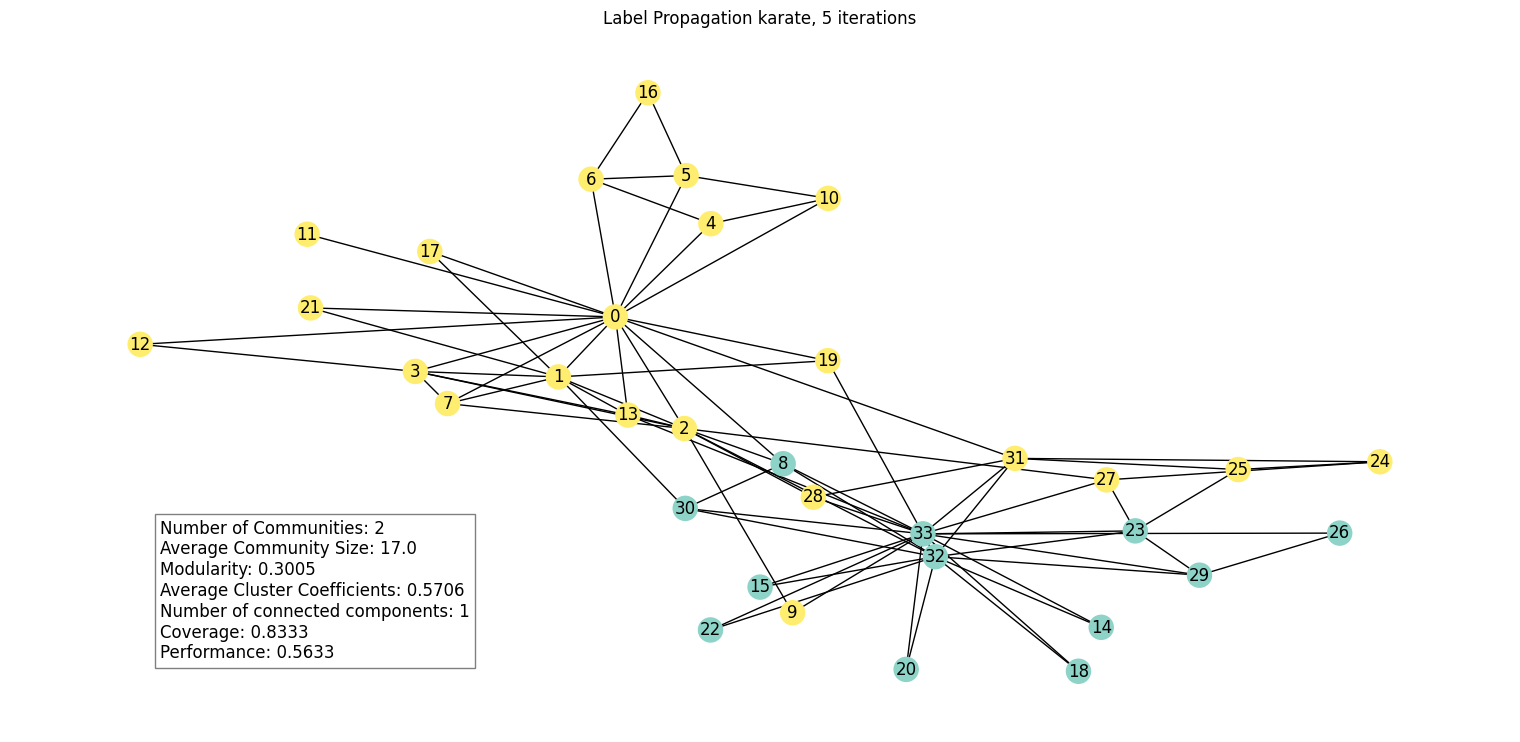

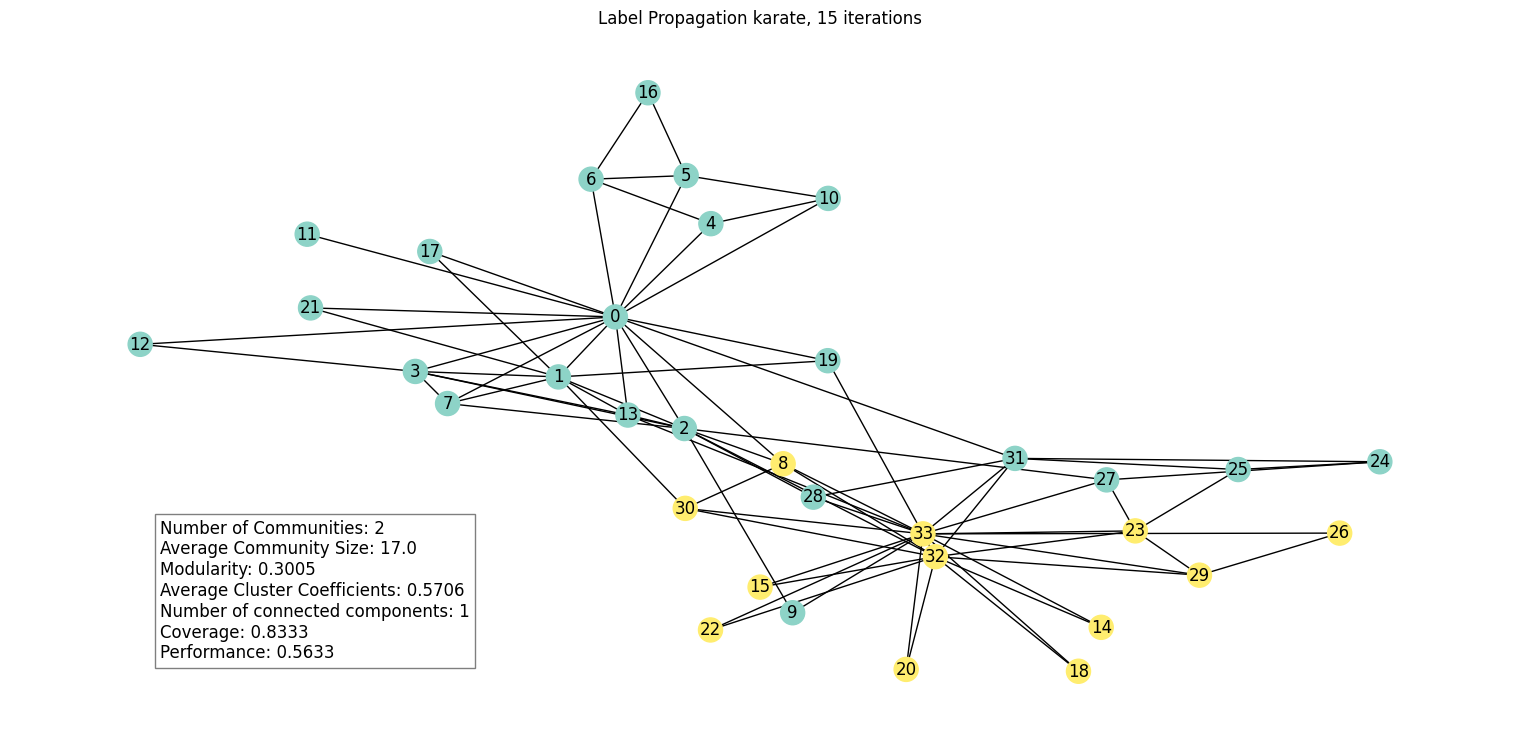

In [14]:
# based on results in paper, experiments with higher value 
# confirm authors' statement that modularity doesn't change much
for i in (1, 5, 15):
    lp_labels = label_propagation(g, aggr_runs=i)

    # Calculate metrics for LP
    lp_metrics = community_metrics(g, lp_labels)
    plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}, {i} iterations", metrics=lp_metrics)
    if lp_metrics["Modularity"] > best_lp_modularity:
        best_i = i

### Model evaluation

In [15]:
# calculate execution time and metrics for best model
start_time = time.time()
lp_labels = label_propagation(g, aggr_runs=best_i)
end_time = time.time()
lp_time = end_time - start_time
lp_metrics = community_metrics(g, lp_labels)

## Louvain

### Hyperparameter selection

For Louvain algorithm, `resolution` hyperparameter will be tuned.

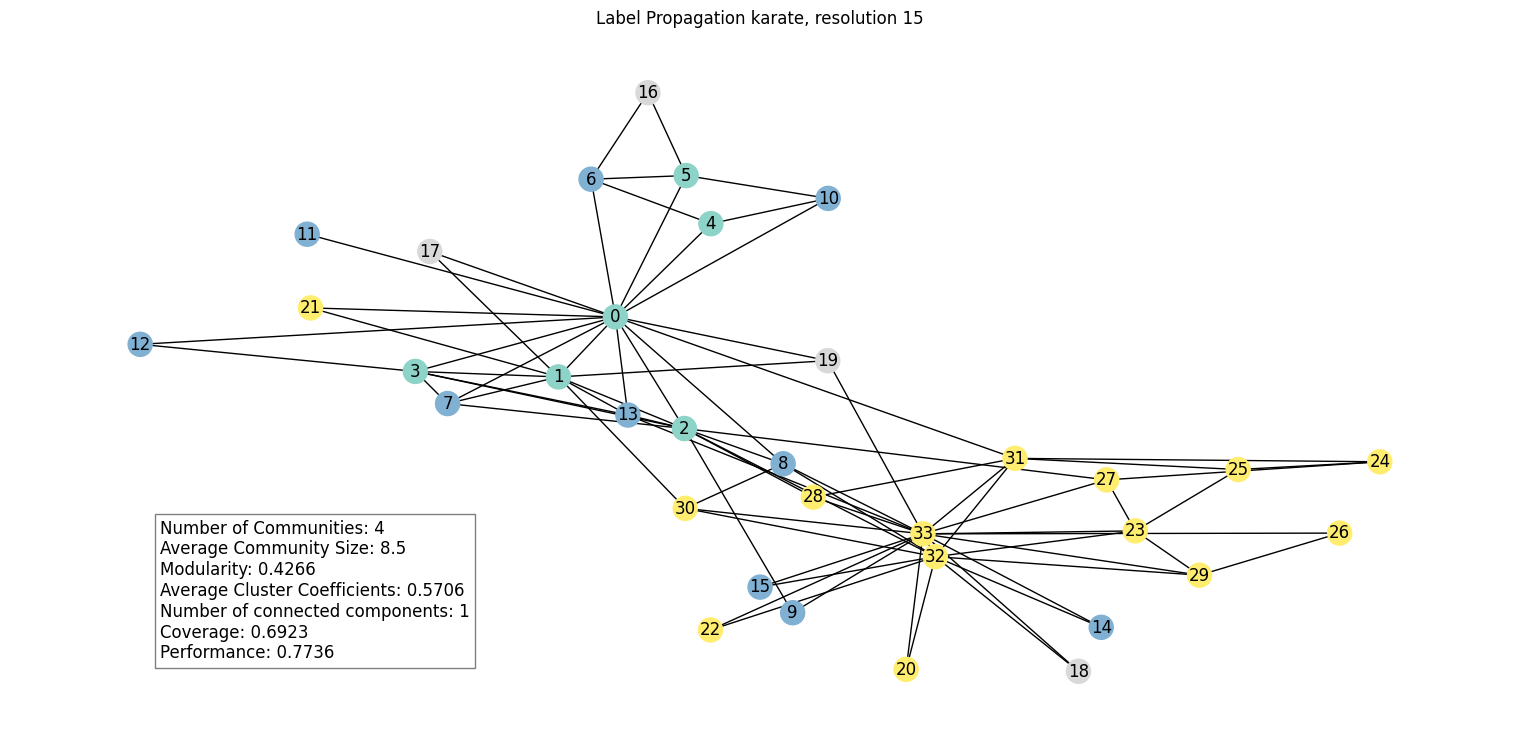

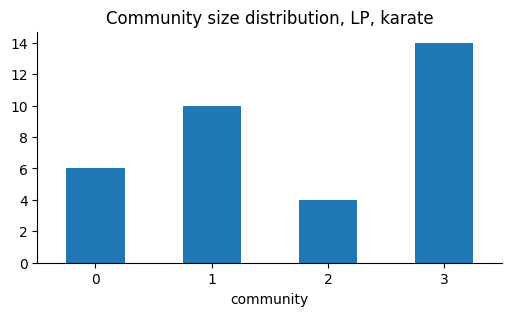

In [16]:
# default resolution
lv_labels = louvain(g)

# Calculate metrics for Louvain
lv_metrics = community_metrics(g, lv_labels)
plot_communities(g, lv_labels, title=f"Label Propagation {sel_graph}, resolution {i}", metrics=lv_metrics)
community_size_hist(lv_labels, title=f"Community size distribution, LP, {sel_graph}")

In [17]:
best_lv_modularity = lv_metrics["Modularity"]
best_resolution = 1

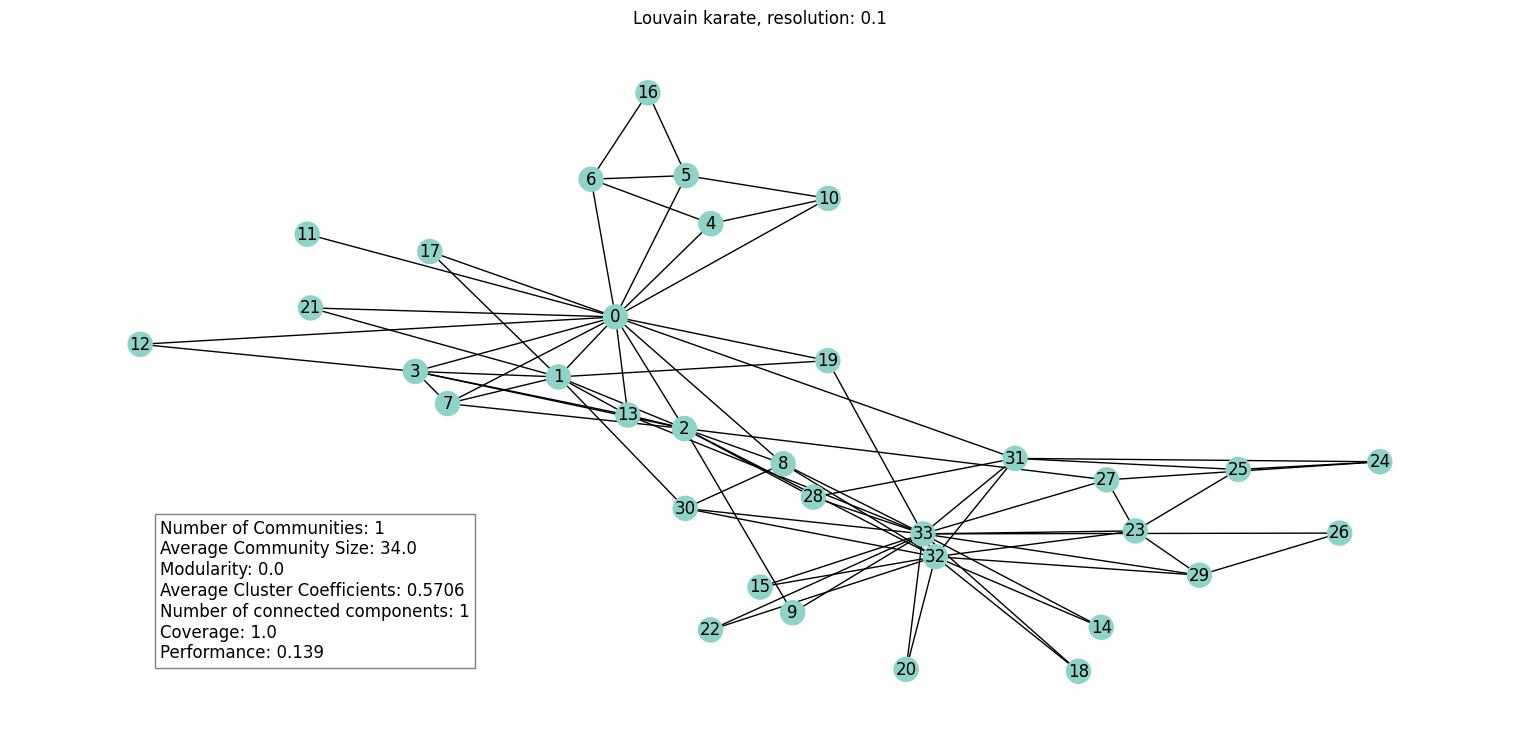

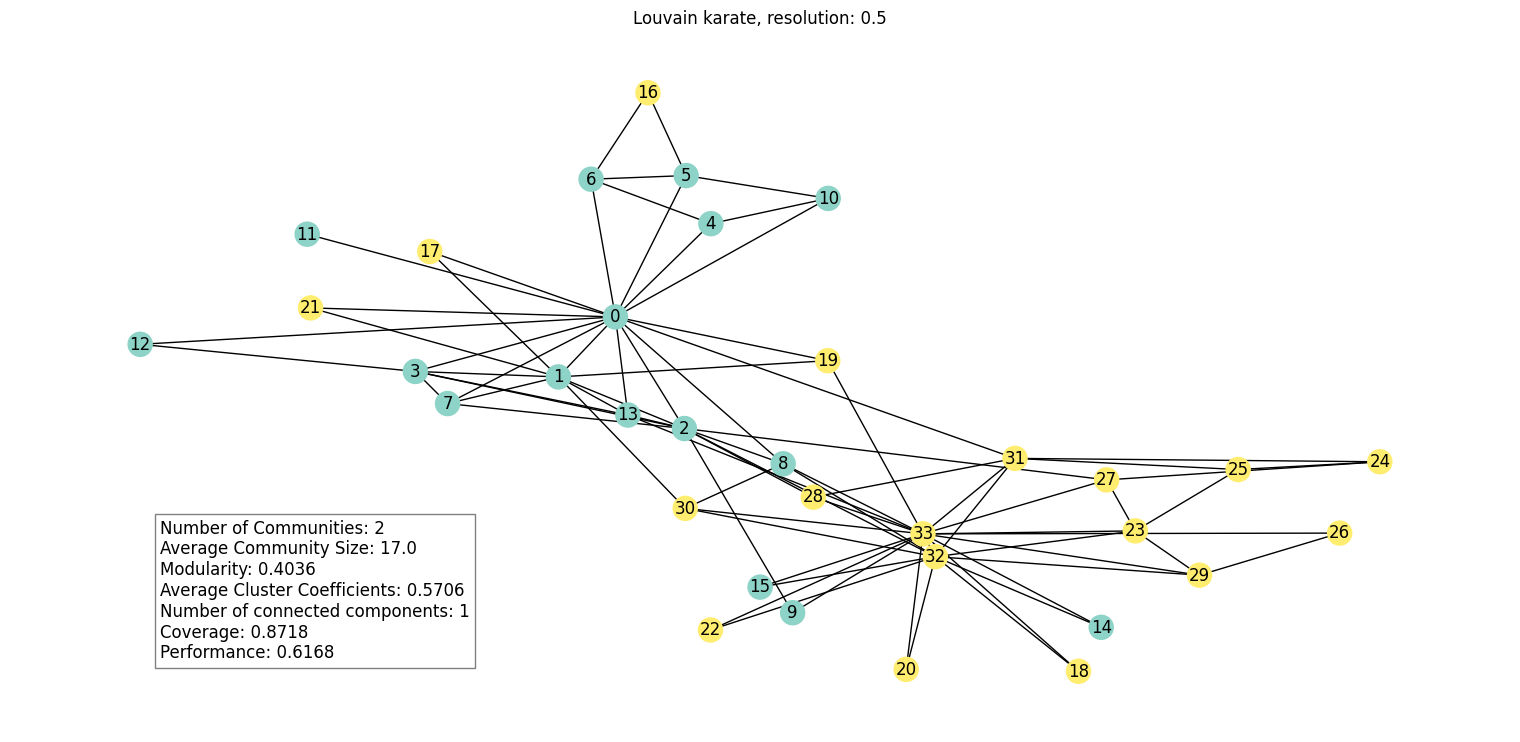

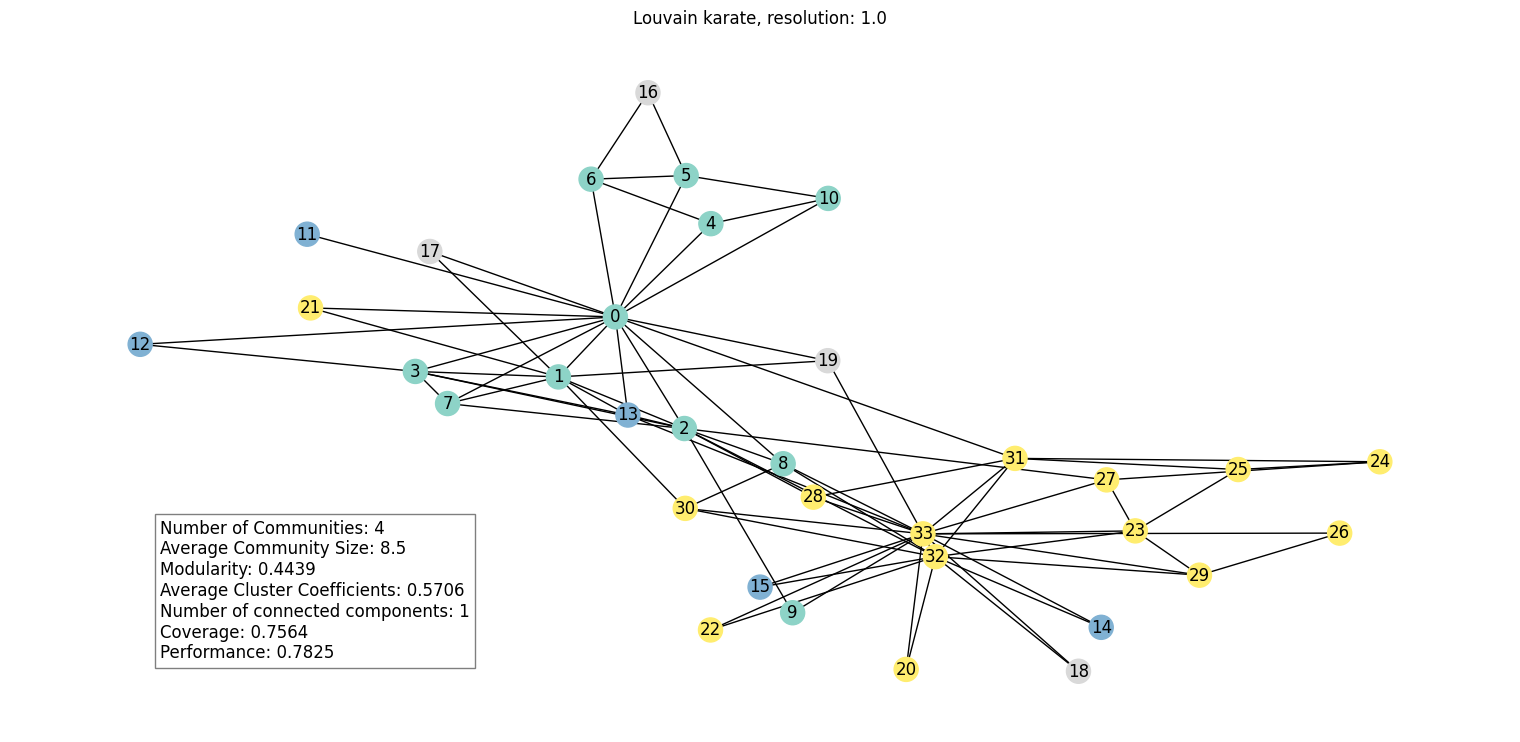

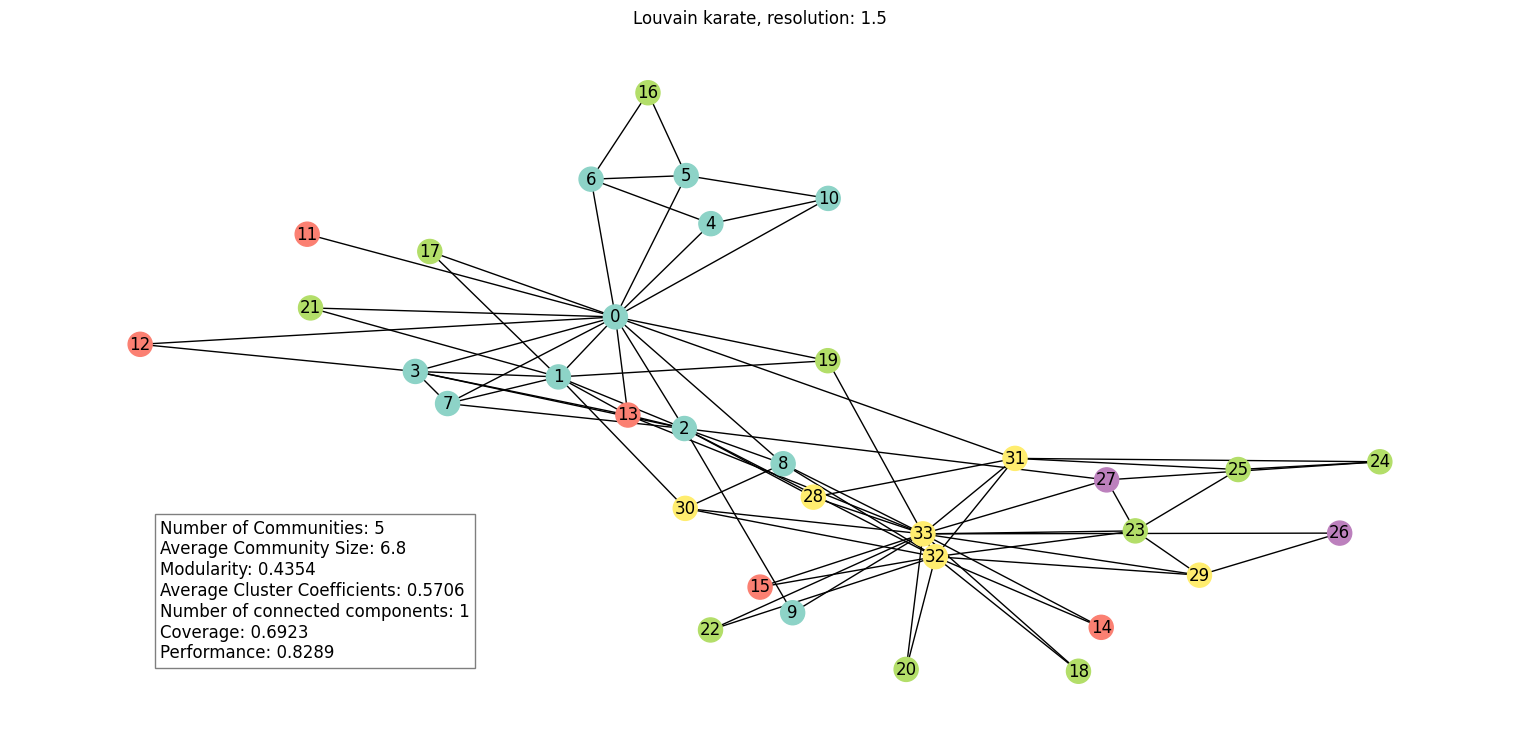

In [18]:
for i in (0.1, 0.5, 1.0, 1.5):
    lv_labels = louvain(g, resolution=i)

    # Calculate metrics for Louvain
    lv_metrics = community_metrics(g, lv_labels)
    plot_communities(g, lv_labels, title=f"Louvain {sel_graph}, resolution: {i}", metrics=lv_metrics)
    if lv_metrics["Modularity"] > best_lv_modularity:
        best_resolution = i

### Model evaluation

In [19]:
# calculate execution time and metrics for best model
start_time = time.time()
lv_labels = louvain(g, resolution=best_resolution)
end_time = time.time()
lv_time = end_time - start_time
lv_metrics = community_metrics(g, lv_labels)

## Leiden

### Hyperparameter selection

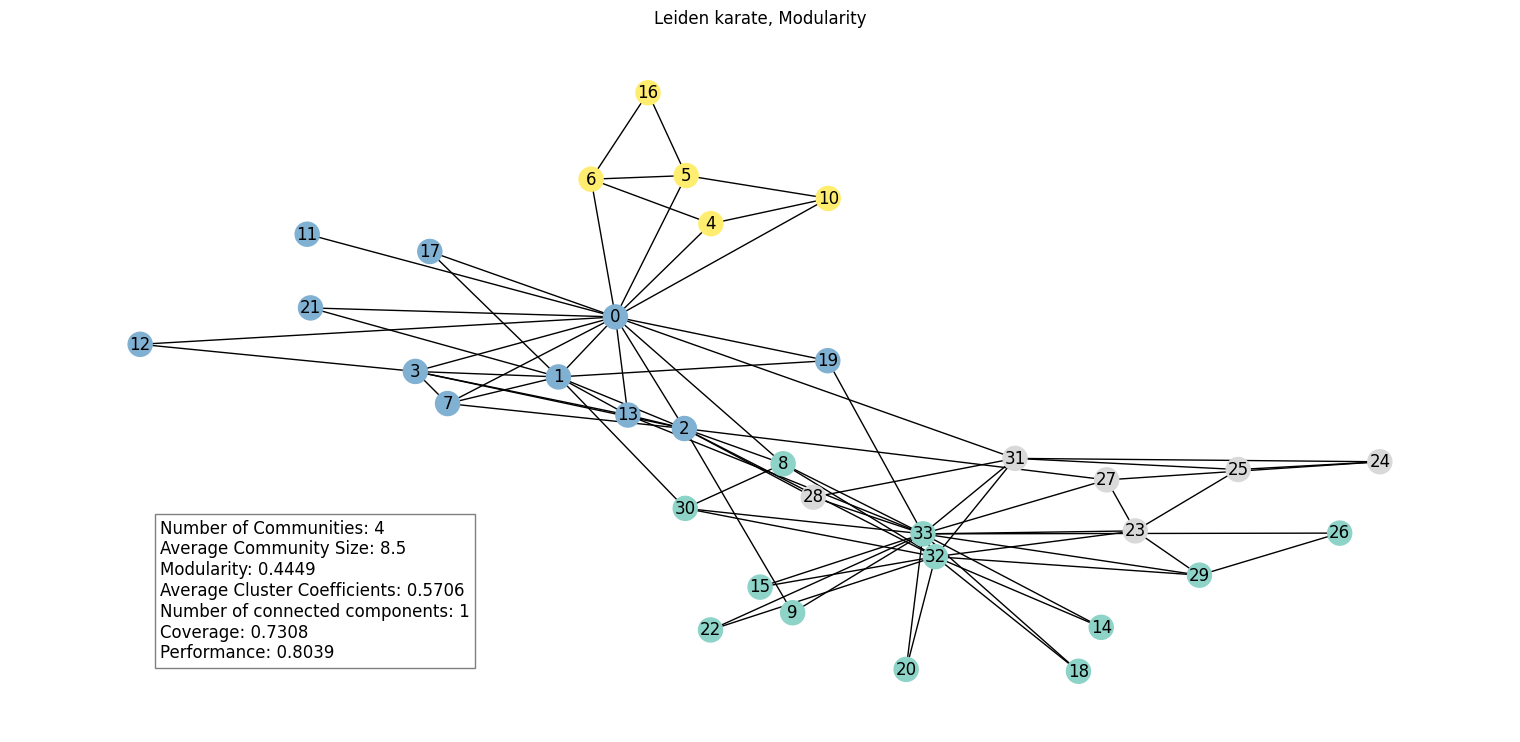

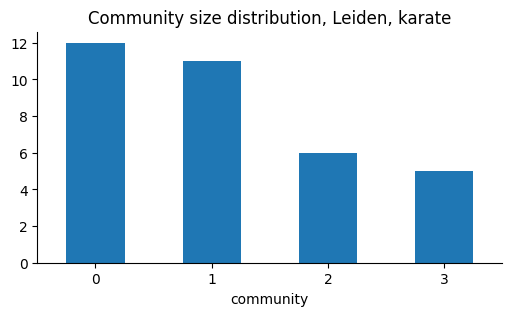

In [20]:
ld_labels = leiden(g)

# Calculate metrics for Leiden
ld_metrics = community_metrics(g, ld_labels)
plot_communities(g, ld_labels, title=f"Leiden {sel_graph}, Modularity", metrics=ld_metrics)
community_size_hist(ld_labels, title=f"Community size distribution, Leiden, {sel_graph}")

In [21]:
best_ld_modularity = ld_metrics["Modularity"]
best_resolution = None

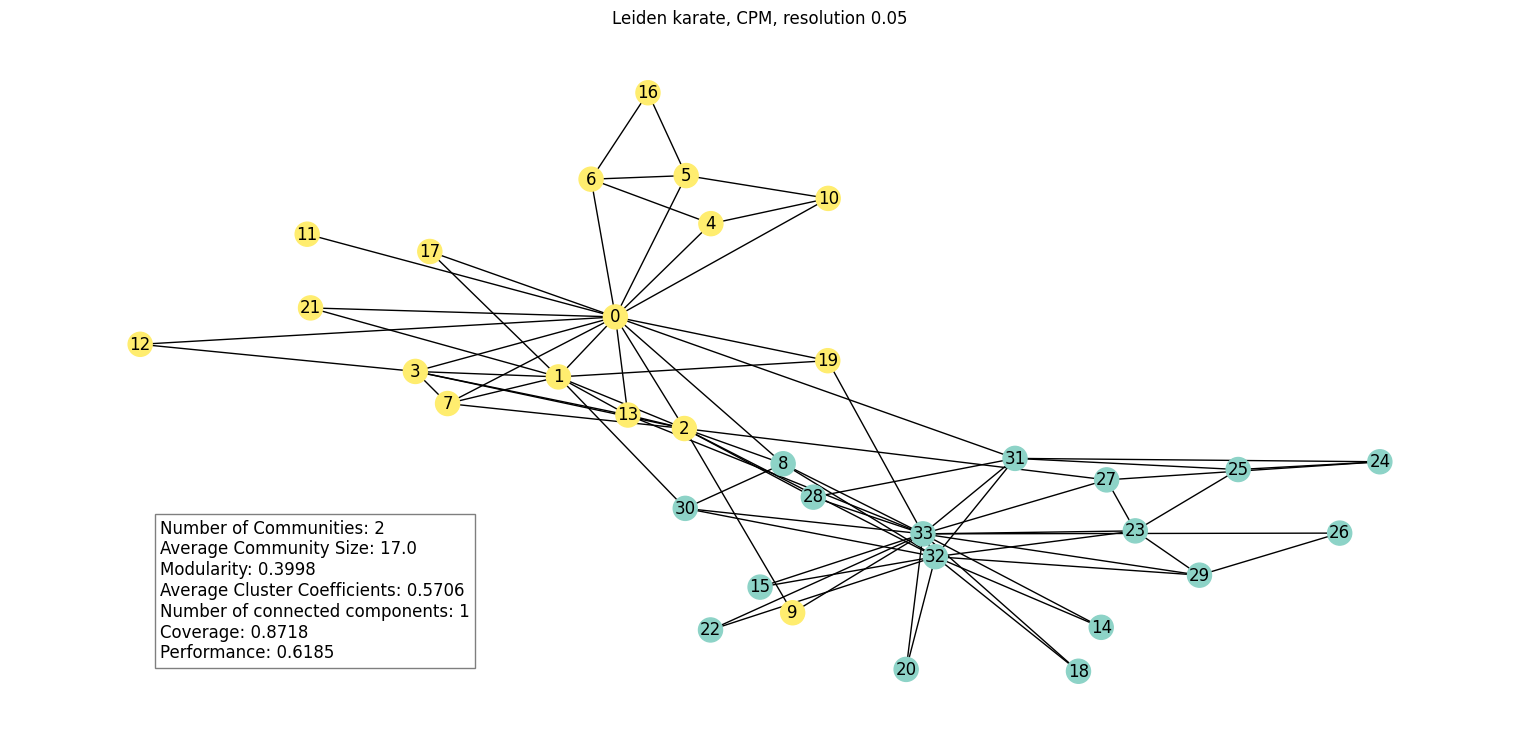

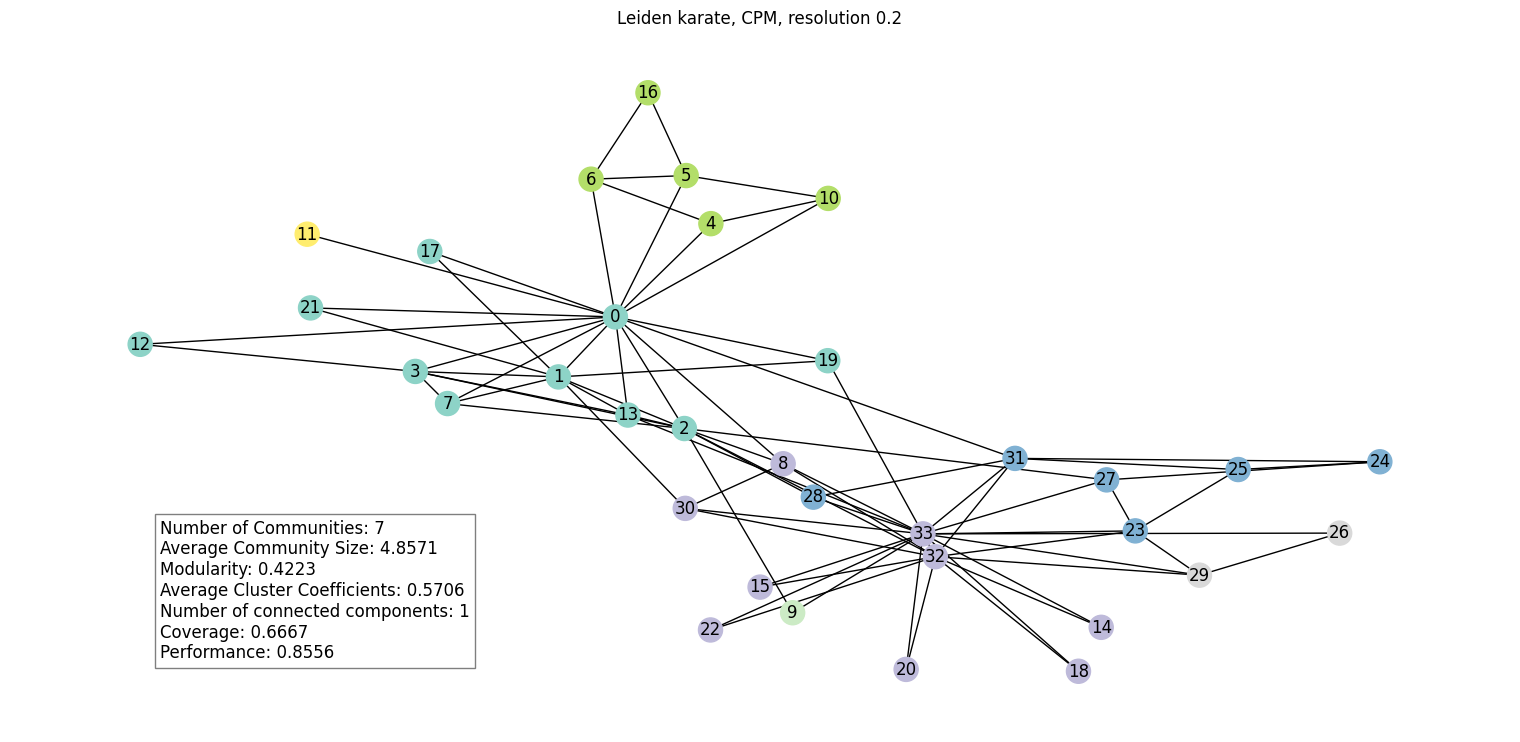

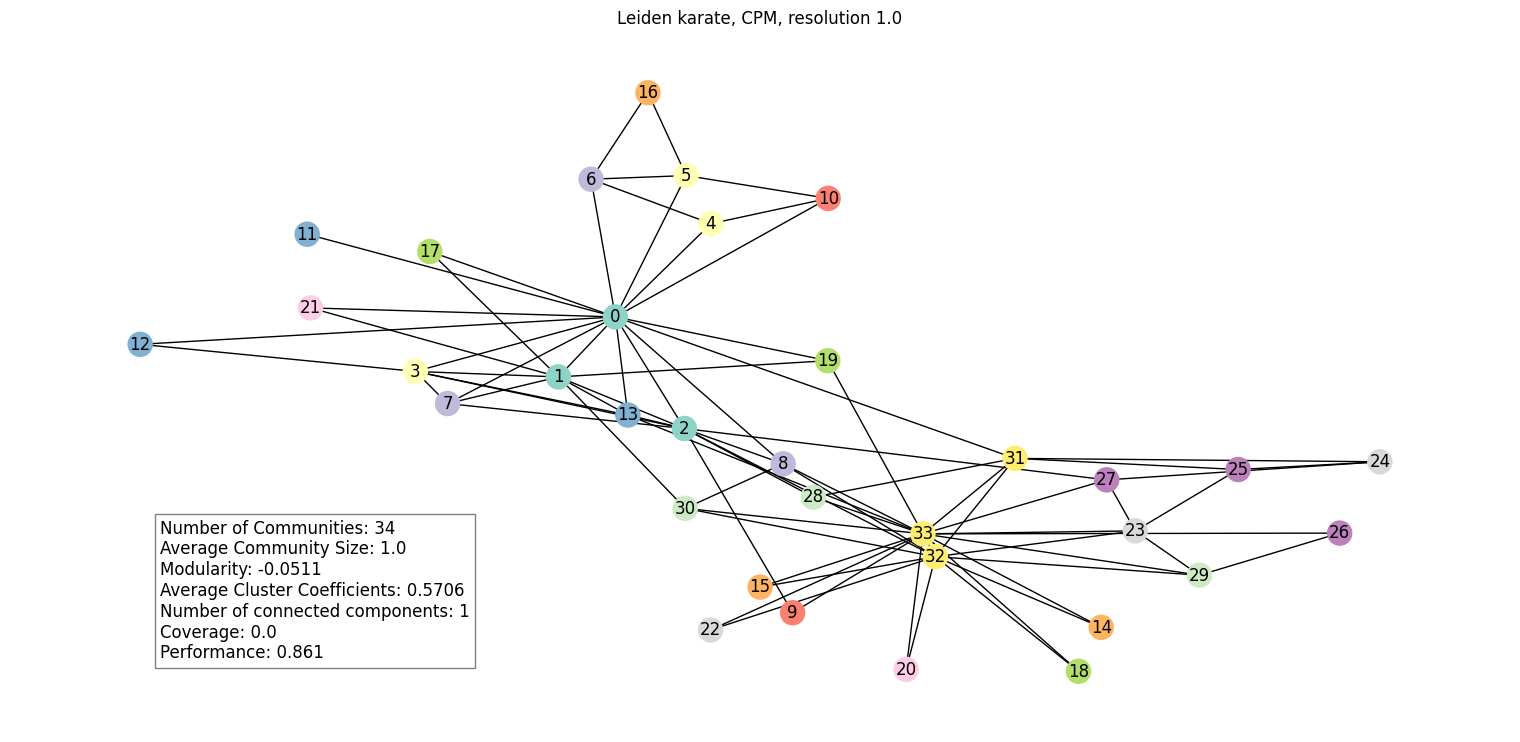

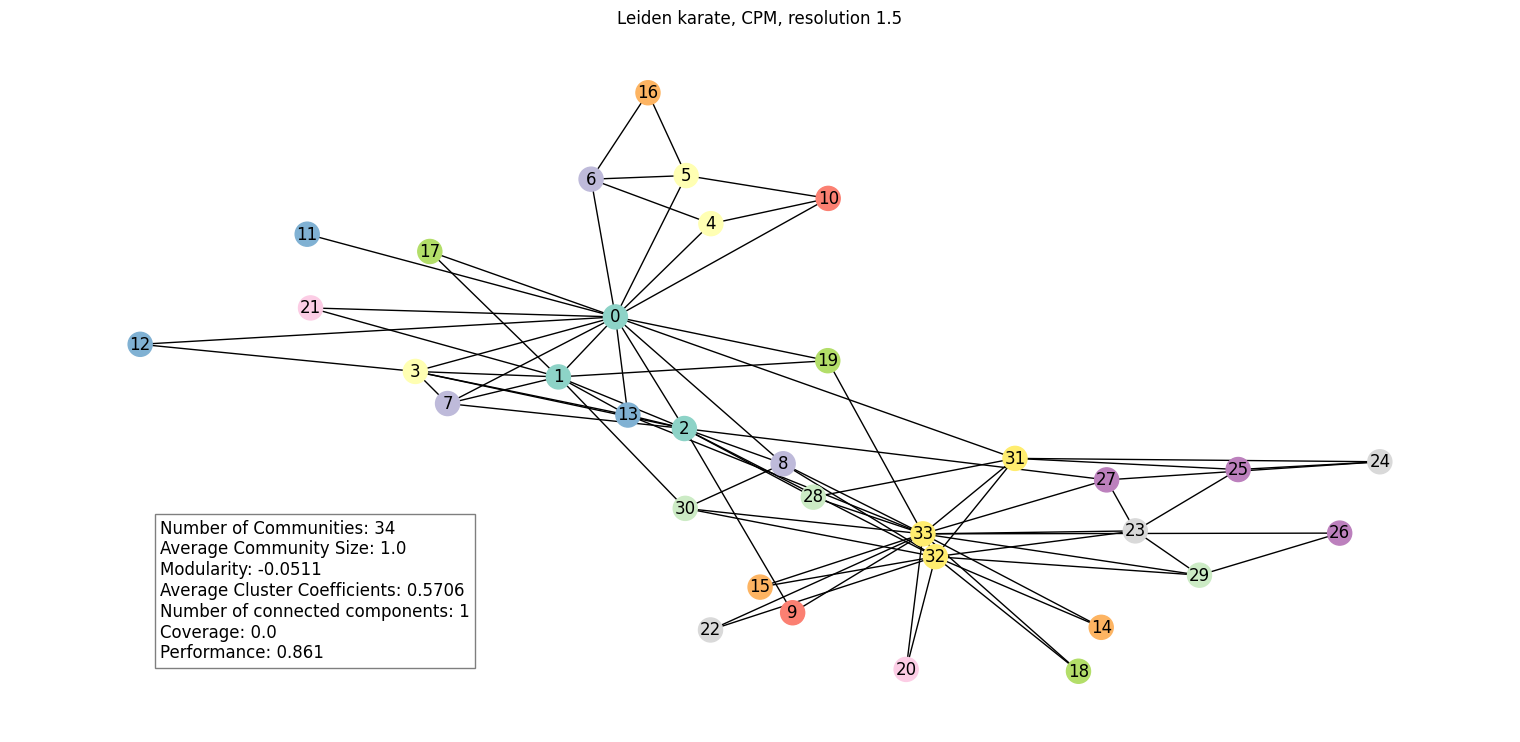

In [22]:
for i in (0.05, 0.2, 1.0, 1.5):
    ld_labels = leiden(g, resolution=i)

    # Calculate metrics for Leiden
    ld_metrics = community_metrics(g, ld_labels)
    plot_communities(g, ld_labels, title=f"Leiden {sel_graph}, CPM, resolution {i}", metrics=ld_metrics)
    if ld_metrics["Modularity"] > best_ld_modularity:
        best_resolution = i

In [23]:
# calculate execution time and metrics for best model
start_time = time.time()
ld_labels = leiden(g)
end_time = time.time()
ld_time = end_time - start_time
ld_metrics = community_metrics(g, ld_labels)

# Apply GAT Embedding

We will try to train GAT using 3 different loss function and compare the obtained results. The loss functions are:
1. DGI (Deep Graph Infomax)
2. Embedding variance
3. Contrastive loss between connected and unconnected nodes


In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [25]:
# Convert networkx graph to PyTorch Geometric data object
data = from_networkx(g)

# Since the graph doesn't have node features, we use an identity matrix
data.x = torch.eye(g.number_of_nodes(), dtype=torch.float)

In [26]:
def predict_with_time(data, model, train_function, epochs, best_clustering_method):
    """
    Helper function to train a model on a provided data with a given train function.
    Returns a tuple (obtained community predictions, time for prediction).
    """
    
    # Start timing
    start_time = time.time()
    
    # Training the model
    for epoch in range(epochs):
        loss = train_function()
        if epoch % 10 == 0:
            print(f'Epoch {epoch}, Loss: {loss}')
    
    # Extract node embeddings
    model.eval()
    with torch.no_grad():
        try:
            node_embeddings = model(data).detach().cpu().numpy()
        except AttributeError:  # case DGI
            node_embeddings = model.encoder(data.x, data.edge_index).cpu().numpy()
    
    if best_clustering_method == "optics":
        # optics clustering
        modularity, best_n, gat_communities = optics(g, node_embeddings)
    else:
        # kmeans clustering
        modularity, best_n, gat_communities = kmeans(g, node_embeddings)
    
    # End timing
    end_time = time.time()
    # Calculate the elapsed time
    elapsed_time = end_time - start_time

    return gat_communities, elapsed_time

## DGI loss

### Hyperparameter selection

In [27]:
# Select best hyperparameters
best_parameters_optuna_dgi = tune(data)

[I 2024-08-13 01:02:48,467] A new study created in memory with name: no-name-d23e0da3-35f8-45bb-90be-7ae71b907f66
[I 2024-08-13 01:02:49,139] Trial 0 finished with value: 0.36431623931623924 and parameters: {'hidden_channels': 12, 'out_channels': 30, 'heads': 3, 'learning_rate': 0.00017781976803220396, 'dropout': 0.45423105289857885, 'weight_decay': 2.742680872537068e-05}. Best is trial 0 with value: 0.36431623931623924.
[I 2024-08-13 01:02:49,520] Trial 1 finished with value: 0.4031886916502301 and parameters: {'hidden_channels': 59, 'out_channels': 16, 'heads': 2, 'learning_rate': 0.00034674838370846184, 'dropout': 0.6538249719570052, 'weight_decay': 0.00010405187043361761}. Best is trial 1 with value: 0.4031886916502301.
[I 2024-08-13 01:02:50,104] Trial 2 finished with value: 0.08473044049967121 and parameters: {'hidden_channels': 13, 'out_channels': 7, 'heads': 7, 'learning_rate': 0.003613419709335532, 'dropout': 0.7945540271092544, 'weight_decay': 0.00033835354360309}. Best is tr

In [28]:
# Best observed modularity
best_parameters_optuna_dgi.best_value

0.41740631163708086

In [29]:
# Save best params
best_parameters = best_parameters_optuna_dgi.best_params

hidden_channels = best_parameters['hidden_channels']
out_channels = best_parameters['out_channels']
heads = best_parameters['heads']
dropout = best_parameters['dropout']
lr = best_parameters['learning_rate']
l2_reg = best_parameters['weight_decay']
epochs = 100
num_layers = 2

best_method = best_parameters_optuna_dgi.best_trial.user_attrs['best_method']

### Model evaluation

In [30]:
# Define DGI model, optimizer, train function for DGI with optimal params
model = DGIModel(in_channels=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_layers=num_layers, heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)


def train():
    model.train()
    optimizer.zero_grad()
    pos_z, neg_z, summary = model(data)
    loss = model.dgi.loss(pos_z, neg_z, summary)
    loss.backward()
    optimizer.step()
    return loss.item()

In [31]:
# get predictions with best model and record time spent on that
gat_dgi_communities, time_dgi = predict_with_time(data, model, train, epochs, best_method)

Epoch 0, Loss: 1.3732644319534302
Epoch 10, Loss: 1.3853754997253418
Epoch 20, Loss: 1.3183397054672241
Epoch 30, Loss: 1.3393722772598267
Epoch 40, Loss: 1.3396966457366943
Epoch 50, Loss: 1.3209034204483032
Epoch 60, Loss: 1.3459160327911377
Epoch 70, Loss: 1.3353300094604492
Epoch 80, Loss: 1.32622230052948
Epoch 90, Loss: 1.2980678081512451


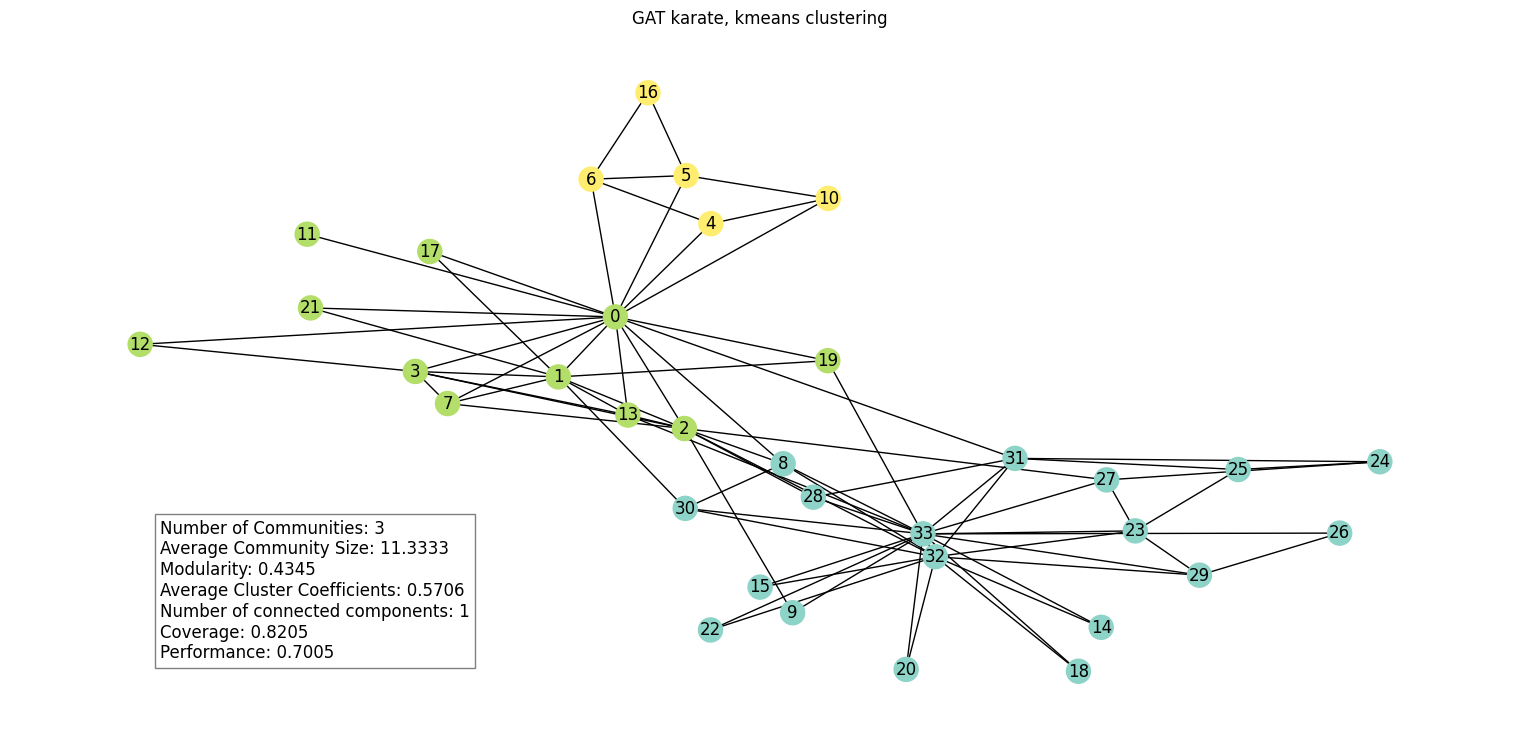

In [32]:
# Print results for the best parameters and best clustering method
gat_dgi_metrics = community_metrics(g, gat_dgi_communities)
plot_communities(g, gat_dgi_communities, title=f"GAT {sel_graph}, {best_method} clustering", metrics=gat_dgi_metrics)

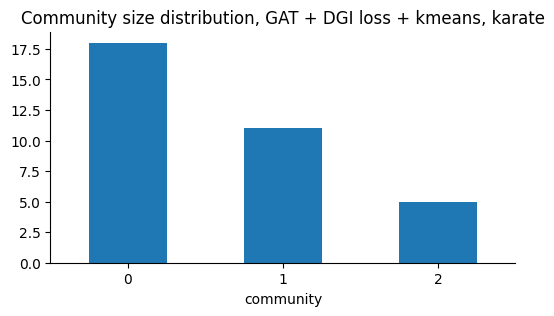

In [33]:
community_size_hist(gat_dgi_communities, title=f"Community size distribution, GAT + DGI loss + {best_method}, {sel_graph}")

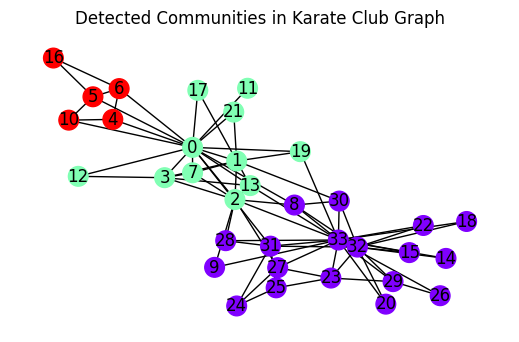

In [34]:
# Plotting the communities
plt.figure(figsize=(5, 3))
nx.draw(g, node_color=list(gat_dgi_communities.values()), with_labels=True, cmap=plt.cm.rainbow, node_size=200)
plt.title("Detected Communities in Karate Club Graph")
plt.show()

## Embedding variance loss

### Hyperparameter selection

In [35]:
best_parameters_optuna_var = tune_variance_contrastive(data, g, loss_function="variance")

[I 2024-08-13 01:03:13,872] A new study created in memory with name: no-name-030a470b-2b88-4e29-b599-e01cbcccf381
[I 2024-08-13 01:03:14,108] Trial 0 finished with value: 0.4241206124323007 and parameters: {'hidden_channels': 36, 'out_channels': 25, 'heads': 4, 'learning_rate': 0.0004325418162803729, 'dropout': 0.2687737434345926, 'weight_decay': 1.4412088501098233e-05}. Best is trial 0 with value: 0.4241206124323007.
[I 2024-08-13 01:03:14,495] Trial 1 finished with value: 0.06395120031483667 and parameters: {'hidden_channels': 57, 'out_channels': 17, 'heads': 5, 'learning_rate': 0.004870949808845209, 'dropout': 0.3546674902335863, 'weight_decay': 3.3446550140647194e-05}. Best is trial 0 with value: 0.4241206124323007.
[I 2024-08-13 01:03:14,927] Trial 2 finished with value: 0.10932141451621973 and parameters: {'hidden_channels': 52, 'out_channels': 30, 'heads': 5, 'learning_rate': 0.004798421485789776, 'dropout': 0.12123952732733596, 'weight_decay': 8.803638505522597e-05}. Best is tr

In [36]:
# Best observed modularity
best_parameters_optuna_var.best_value

0.44490358126721763

In [37]:
best_parameters = best_parameters_optuna_var.best_params

hidden_channels = best_parameters['hidden_channels']
out_channels = best_parameters['out_channels']
heads = best_parameters['heads']
dropout = best_parameters['dropout']
lr = best_parameters['learning_rate']
l2_reg = best_parameters['weight_decay']
epochs = 100
num_layers = 2

best_method = best_parameters_optuna_var.best_trial.user_attrs['best_method']

### Model evaluation

In [38]:
# Define GAT model with embedding variance loss functions
# Define optimizer, train function for GAT with optimal params
model = GAT(num_features=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = -torch.var(out)
    loss.backward()
    optimizer.step()
    return loss.item()

In [39]:
# get predictions with best model and record time spent on that
gat_var_communities, time_var = predict_with_time(data, model, train, epochs, best_method)

Epoch 0, Loss: -0.007017060182988644
Epoch 10, Loss: -0.0068880910985171795
Epoch 20, Loss: -0.008468084037303925
Epoch 30, Loss: -0.009922034107148647
Epoch 40, Loss: -0.008316799066960812
Epoch 50, Loss: -0.011202354915440083
Epoch 60, Loss: -0.010280265472829342
Epoch 70, Loss: -0.010354112833738327
Epoch 80, Loss: -0.012154271826148033
Epoch 90, Loss: -0.011915176175534725


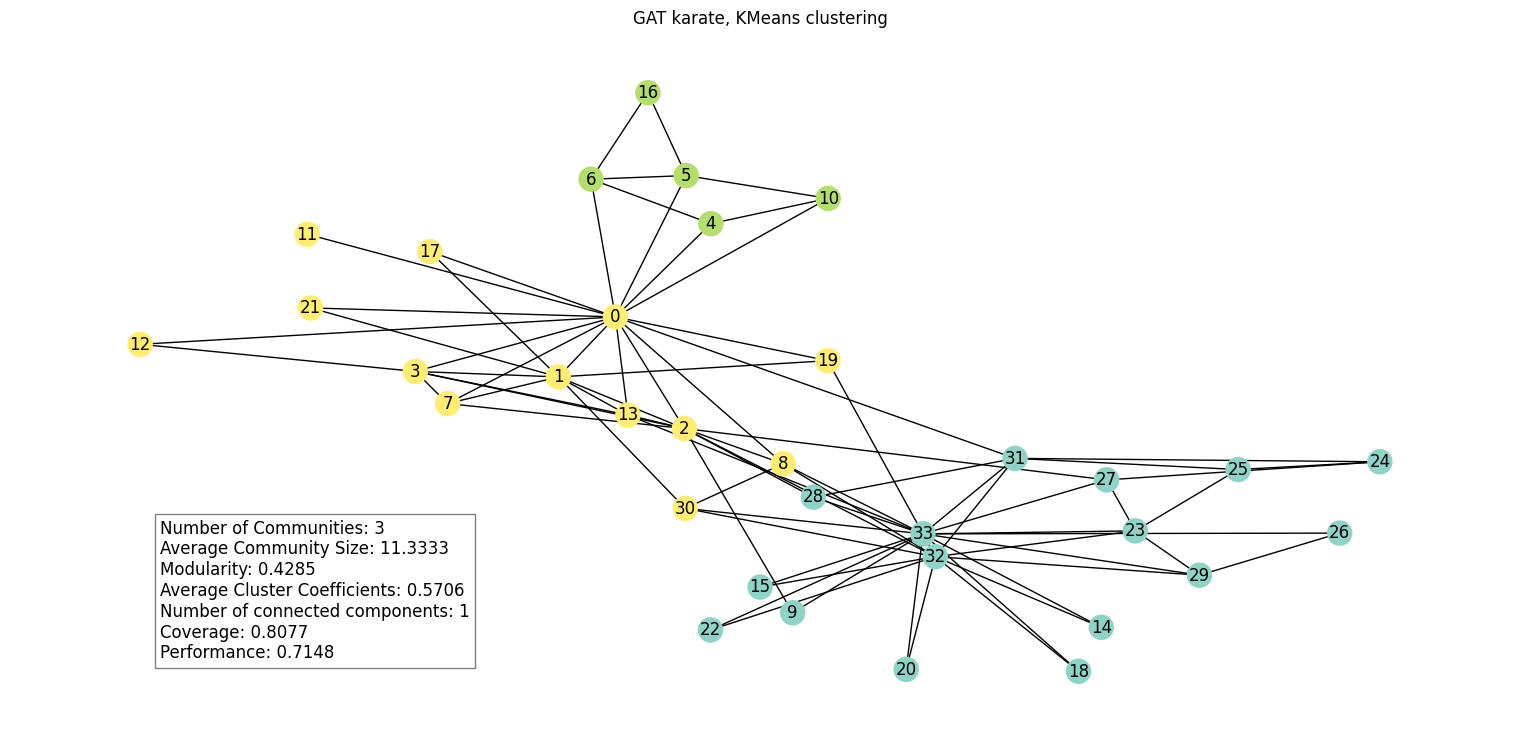

In [40]:
# get visualizations and metrics
gat_var_metrics = community_metrics(g, gat_var_communities)
plot_communities(g, gat_var_communities, title=f"GAT {sel_graph}, KMeans clustering", metrics=gat_var_metrics)

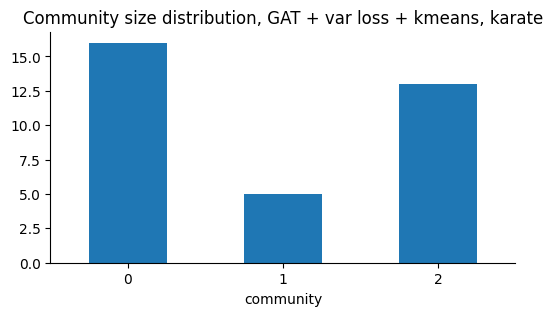

In [41]:
community_size_hist(gat_var_communities, title=f"Community size distribution, GAT + var loss + {best_method}, {sel_graph}")

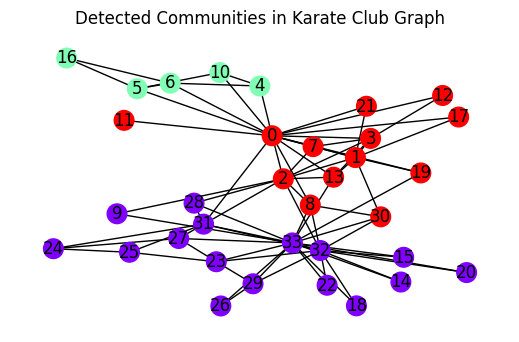

In [42]:
# Plotting the communities
plt.figure(figsize=(5, 3))
nx.draw(g, node_color=list(gat_var_communities.values()), with_labels=True, cmap=plt.cm.rainbow, node_size=200)
plt.title("Detected Communities in Karate Club Graph")
plt.show()

## Contrastive loss

### Hyperparameter selection

In [43]:
best_parameters_optuna_con = tune_variance_contrastive(data, g, loss_function="contrastive")

[I 2024-08-13 01:03:31,568] A new study created in memory with name: no-name-e91ec72e-0796-4c06-bc4f-589cdd8f9556
[I 2024-08-13 01:03:33,456] Trial 0 finished with value: 0.41401023219205035 and parameters: {'hidden_channels': 62, 'out_channels': 23, 'heads': 8, 'learning_rate': 0.0012706633969472628, 'dropout': 0.5356510182680494, 'weight_decay': 0.0005131226207479928}. Best is trial 0 with value: 0.41401023219205035.
[I 2024-08-13 01:03:35,279] Trial 1 finished with value: 0.44490358126721763 and parameters: {'hidden_channels': 62, 'out_channels': 15, 'heads': 2, 'learning_rate': 0.0034165376513463383, 'dropout': 0.24242884191227798, 'weight_decay': 0.00011417242382217075}. Best is trial 1 with value: 0.44490358126721763.
[I 2024-08-13 01:03:37,137] Trial 2 finished with value: 0.43835385393826953 and parameters: {'hidden_channels': 9, 'out_channels': 19, 'heads': 4, 'learning_rate': 0.0031471862331574597, 'dropout': 0.1443289839205839, 'weight_decay': 1.8627960561794296e-05}. Best i

In [44]:
# Best observed modularity
best_parameters_optuna_con.best_value

0.44490358126721763

In [45]:
best_parameters = best_parameters_optuna_con.best_params

hidden_channels = best_parameters['hidden_channels']
out_channels = best_parameters['out_channels']
heads = best_parameters['heads']
dropout = best_parameters['dropout']
lr = best_parameters['learning_rate']
l2_reg = best_parameters['weight_decay']
epochs = 100

best_clustering_method = best_parameters_optuna_con.best_trial.user_attrs['best_method']

### Model evaluation

In [46]:
# Define GAT model with contrastive loss functions
# Define optimizer, train function for GAT with optimal params

model = GAT(num_features=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = contrastive_loss(out, g)
    loss.backward()
    optimizer.step()
    return loss.item()

In [47]:
gat_con_communities, time_con = predict_with_time(data, model, train, epochs, best_method)

Epoch 0, Loss: 0.49164801836013794
Epoch 10, Loss: 0.11333795636892319
Epoch 20, Loss: 0.07414305210113525
Epoch 30, Loss: 0.060418546199798584
Epoch 40, Loss: 0.048614390194416046
Epoch 50, Loss: 0.06236118823289871
Epoch 60, Loss: 0.06547699868679047
Epoch 70, Loss: 0.05081319063901901
Epoch 80, Loss: 0.04463815316557884
Epoch 90, Loss: 0.04998413100838661


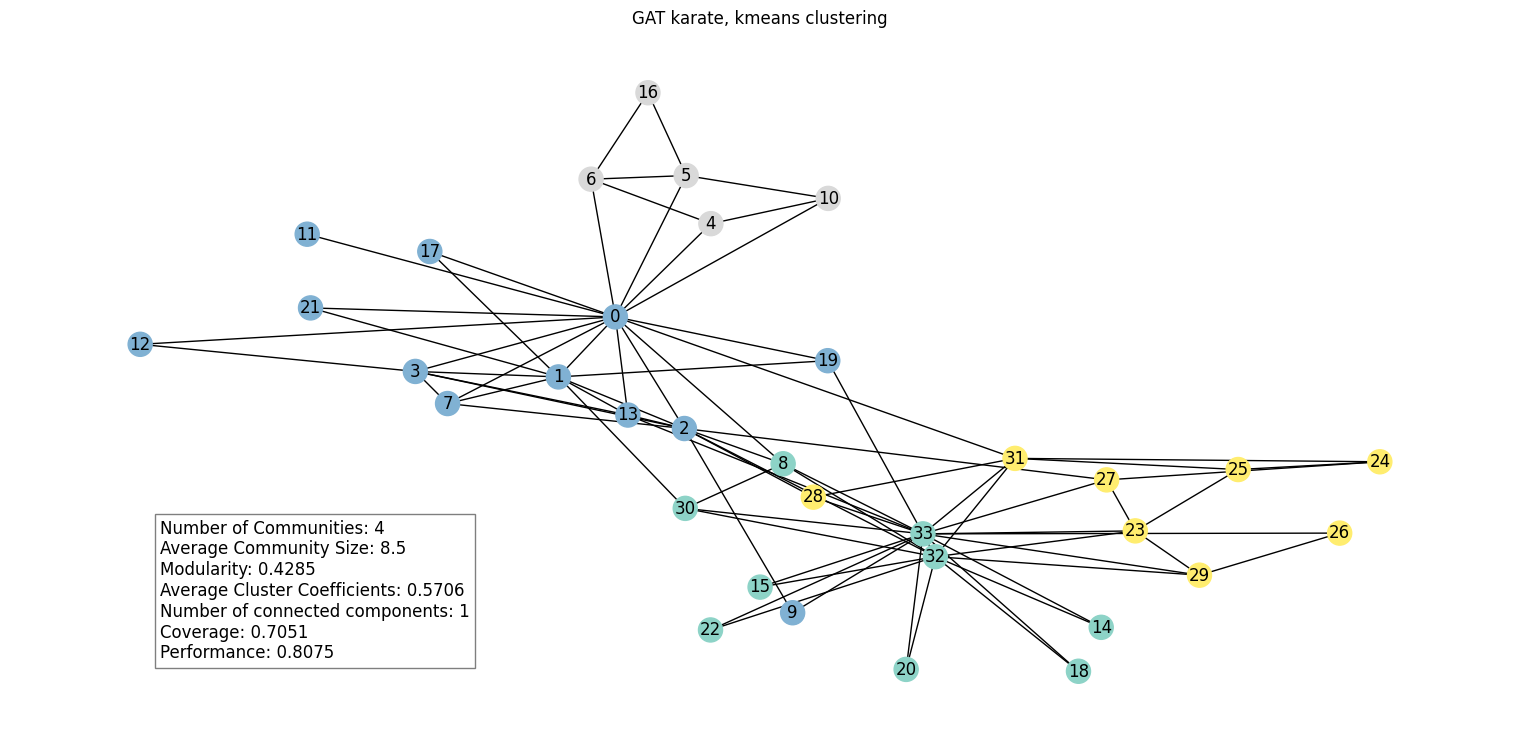

In [48]:
gat_con_metrics = community_metrics(g, gat_con_communities)
plot_communities(g, gat_con_communities, title=f"GAT {sel_graph}, {best_method} clustering", metrics=gat_con_metrics)

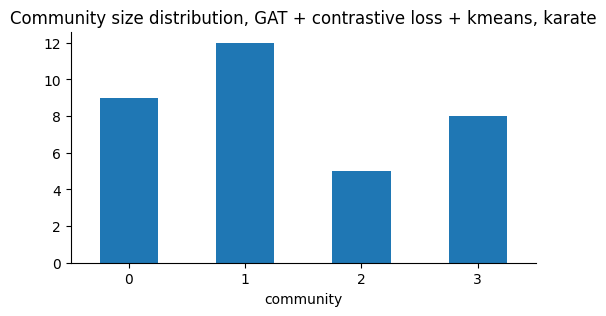

In [49]:
community_size_hist(gat_con_communities, title=f"Community size distribution, GAT + contrastive loss + {best_method}, {sel_graph}")

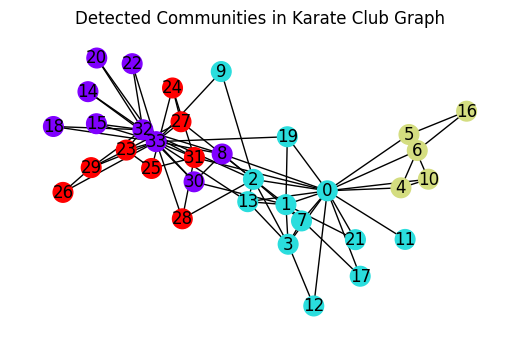

In [50]:
# Plotting the communities
plt.figure(figsize=(5, 3))
nx.draw(g, node_color=list(gat_con_communities.values()), with_labels=True, cmap=plt.cm.rainbow, node_size=200)
plt.title("Detected Communities in Karate Club Graph")
plt.show()

# Final result

## Modularities

In [51]:
lp_metrics["Modularity"]

0.30948632896684847

In [52]:
lv_metrics["Modularity"]

0.418142463597009

In [53]:
ld_metrics["Modularity"]

0.44490358126721763

In [54]:
gat_dgi_metrics["Modularity"]

0.4345214669889994

In [55]:
gat_var_metrics["Modularity"]

0.4284870973182662

In [56]:
gat_con_metrics["Modularity"]

0.4285058375967467

## Execution times (CPU)

In [57]:
lp_time

0.0002620220184326172

In [58]:
lv_time

0.0008759498596191406

In [59]:
ld_time

0.0014929771423339844

In [60]:
time_dgi

0.27961182594299316

In [61]:
time_var

0.11605286598205566

In [62]:
time_con

1.8262579441070557